In [1]:
import sys
import os
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Change to project root directory
os.chdir('..')
print(f"Current directory: {os.getcwd()}")

from src.kitchen_simulator import generate_dataset

plt.style.use('ggplot')
%matplotlib inline

Current directory: c:\Users\imnee\OneDrive\Desktop\kpt-prediction


In [2]:
# Generate dataset
df = generate_dataset(10000)
print(f"Generated {len(df)} orders")
df.head()

Generated 10000 orders
Generated 10000 orders


,order_id,merchant_id,timestamp,hour,is_rush,true_kpt,concurrent_orders,rush_multiplier
0,ORD_00000,M002,2026-01-13 22:25:00,22,False,14.459791,1,1.000000
1,ORD_00001,M001,2026-01-02 00:39:00,0,False,24.308642,7,1.000000
2,ORD_00002,M003,2026-01-26 03:37:00,3,False,10.442954,2,1.000000
3,ORD_00003,M003,2026-01-22 01:02:00,1,False,10.091031,1,1.000000
4,ORD_00004,M003,2026-01-22 12:43:00,12,True,18.205427,3,1.493753


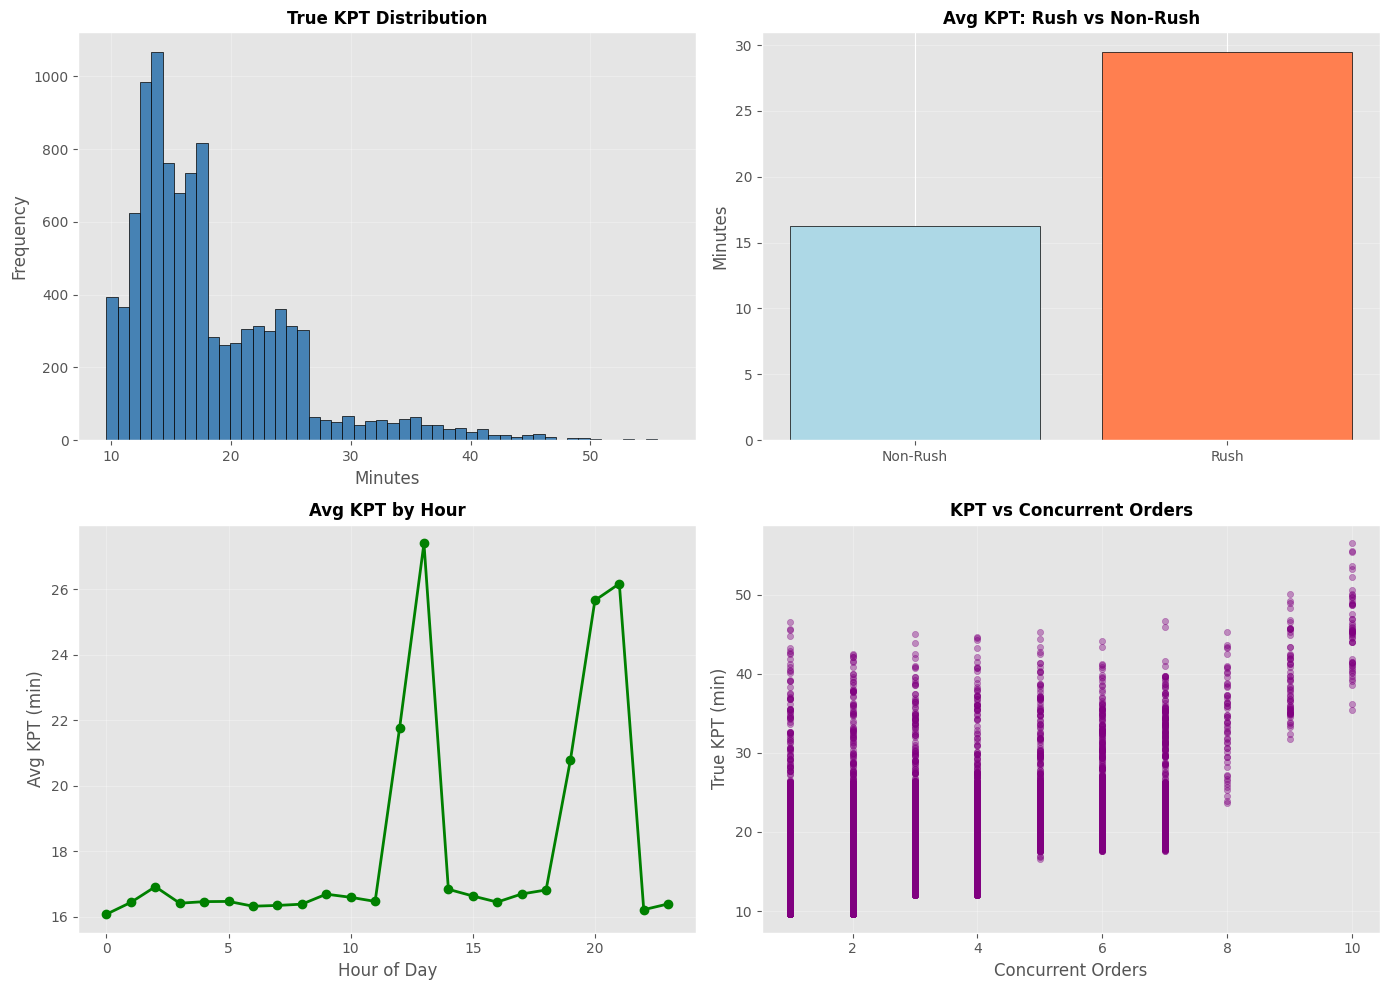

Saved: results/data_exploration.png


In [3]:
# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KPT distribution
axes[0,0].hist(df['true_kpt'], bins=50, edgecolor='black', color='steelblue')
axes[0,0].set_title('True KPT Distribution', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Minutes')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(True, alpha=0.3)

# Rush vs Non-rush
rush_means = df.groupby('is_rush')['true_kpt'].mean()
axes[0,1].bar(['Non-Rush', 'Rush'], rush_means.values, color=['lightblue', 'coral'], edgecolor='black')
axes[0,1].set_title('Avg KPT: Rush vs Non-Rush', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Minutes')
axes[0,1].grid(True, alpha=0.3, axis='y')

# Hourly pattern
hourly_avg = df.groupby('hour')['true_kpt'].mean()
axes[1,0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, color='green')
axes[1,0].set_title('Avg KPT by Hour', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Avg KPT (min)')
axes[1,0].grid(True, alpha=0.3)

# Concurrent orders impact
axes[1,1].scatter(df['concurrent_orders'], df['true_kpt'], alpha=0.4, color='purple', s=20)
axes[1,1].set_title('KPT vs Concurrent Orders', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Concurrent Orders')
axes[1,1].set_ylabel('True KPT (min)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/data_exploration.png")

In [4]:
# Summary statistics
print("\nDataset Summary:")
print(f"Total orders: {len(df)}")
print(f"Rush orders: {df['is_rush'].sum()} ({df['is_rush'].mean()*100:.1f}%)")
print(f"\nKPT Statistics:")
print(f"Mean: {df['true_kpt'].mean():.2f} min")
print(f"Median: {df['true_kpt'].median():.2f} min")
print(f"P90: {df['true_kpt'].quantile(0.9):.2f} min")
print(f"Std: {df['true_kpt'].std():.2f} min")


Dataset Summary:
Total orders: 10000
Rush orders: 1435 (14.3%)

KPT Statistics:
Mean: 18.18 min
Median: 16.32 min
P90: 26.04 min
Std: 6.73 min
